## Import Packages

In [1]:
import numpy as np

import matplotlib.pyplot as plt

from scipy.optimize import curve_fit
from scipy.optimize import brentq

import scipy.stats as st

import random

import math

from astropy.time import Time
from astropy import units as u

from datetime import datetime

## Set Input Parameters and Fixed Quantities

## User Choices for Notebook Run

In [2]:
# Type of historical uM hit WFE estimates used as the basis of calculations:
#    1 : Model values obtained by fitting segement-level features on OPD maps from WFS data
#    2 : Observed values inferred from segement-level WFE increases in OPD maps from WFS data
# Either way, PTT (piston, tip, and tilt) have been removed from the RMS, because those are routinely 
# corrected with WFC activities anyway, and do not represent a deformation of the segment. 
# The recommended default is 1, which was also used for the Telfer et al. (2026) TR, 
# but results for 2 are not fundamentally different. The low-WFE distribution is fairly different,
# but the large-WFE distribution is similar, which is what dominates the longer-term evolution.  
iobstype = 1

if iobstype not in (1, 2):
        raise ValueError(f"Invalid value: iobstype must be 1 or 2")

In [3]:
# Type of fit done to observed uM data. In all cases include only hits above rmsminfit.
#    1 : Fit the cumulative distribution points in linear-linear space
#    2 : Fit the cumulative distribution points in lon-log space, using midpoints to approximate the staircase nature of the 
#            observed distribution
#    3 : As 1, but keep large-RMS parameters fixed to those used in the Telfer et al. 2026)
# The choice 1 is the most optimistic (in the sense that it yields the lowest reasonable tail
#   for high-WFE uM hits, and hence the slowest OTE degradation). 
# The choice 2 is the most conservative (in the sense that it yields the broadest reasonable tail
#   for high-WFE uM hits, and hence the fastest OTE degradation). 
# The choice 3 is most similar to what was published in Telfer et al., but it won't adjust the slope of
#   its tail for high-WFE uM hits in response to new data. 
# Comparison of results for the different fit types, 1 and 2 in partiocular, gives a sense of systematic uncertainties in the 
# future predictions.
ifittype = 2

if ifittype not in (1, 2, 3):
        raise ValueError(f"Invalid value: ifittype must be 1, 2, or 3")

In [4]:
# Type of correction applied to uM damage
#    0: piston, tip, tilt only
#    1: the previous, plus also radius of curvature
#    2: the previous, plus also clocking and translation
# 0 is what is routinely done for every WFC activity. 1 is what has been done for bigger hits. 
# 2 would be beneficial and could be done, but has not been routinely done except for the 2022 C3 hit.
# So choosing 1 would be most representative of the current state of OTE operational maintenance.
icortype = 1

if icortype not in (0, 1, 2):
        raise ValueError(f"Invalid value: icortype must be 0, 1, 2")

### Set the Current OTE State

In [5]:
# Today's date in decimal years
input_date = datetime.now()
astropy_time_object = Time(input_date, format='datetime')
today = astropy_time_object.decimalyear
print(f"The current date as a digitial calendar year is: {today:.4f}")

# Initial RMS OTE WFE at the current time, i.e., at the start of the simulated future.
# This should be baseline that can be achieved after a standard WFC activity, not the actual current RMS.
# This number can be found at https://wsstas.stsci.edu/wsstas/, top-left plot labeled "RMSEFE", bottom panel,
# right-most red dot. If this notebook were to be implement onto that website, then this number should
# ideally be read from file so as to automatically yield the most-recent value, as opposed to hardcoding it here. 
# The hardcoded value listed here was correct in late March 2026.
rmsOTEini = 65.07

The current date as a digitial calendar year is: 2026.2348


### Set uM Model parameters

In [6]:
# The input file from which uM data are read.
# The latest version of this is found on STScI Central Store at
# /itar/jwst/tel/share/WFSC/Micrometeoroid_reference/jwst_hist_MM_summary.xls .
# Here we read instead a version from March 2026.
infile = 'jwst_hist_MM_summary.xls'

In [7]:
# The segment level RMS value below which detections are not believed to be complete. 
# Lower values are excluded from the fit of the uM probability distribution.
# Based on the plots below, we allow for different cutoffs depending on which input metric of RMS WFE we are using. 
if iobstype == 1:
    rmsminfit = 2.5
elif iobstype == 2: 
    rmsminfit = 4.0
else:
    raise ValueError(f"Invalid value: iobstype must be 1 or 2")    

In [8]:
# The minimum and maximum segment-level RMS wavefront error that are included in Monte-carlo calculations of 
# the future WFE evolution 
rmsminevol = 1.0
rmsmaxevol = 1000.0

# Note that the future evolution is sensitive to the high cutoff, as already shown in Figure 36 of the Telfer et al.
# (2026) TR. Instead, the results are not sensitive to the low cutoff, since the long-term damage to the OTE is dominated
# by the largest hits.

### Set Numerical Calculation Parameters

In [9]:
# Number of samples in Monte-Carlo drawing test
# This is not used in the final analysis. 
NMC = 100000

# Spacing of each timeline in days
# This should be small enough to have sufficiently low probability of getting two uMs hits
# in a single bin, a situation that the code does not address.
tbin = 0.25

# Number of timeline points to simulate
# Together with tbin this determines how far into the future the OTE evolution is simulated.
Nt = 100000

# Numbers of timelines to draw. This sets the noise on the final results.  
# Note that 1000 yields low-noise curves suitable for analysis. This takes 1-2 min to run omn a laptop.
# Lower numbers can be used for test runs.
Nevol = 1000

# The minimum and maximum segment-level RMS wavefront error that are included in Monte-carlo drawings.
# Note that only values between rmsminevol and rmsmaxevol are actually used in modeling the future WFE evolution.
rmsmindraw = rmsminevol
rmsmaxdraw = 10 * rmsmaxevol

if (rmsmindraw > rmsminevol) or (rmsmaxdraw < rmsmaxevol):
        raise ValueError(f"Drawing range not wide enough")    

### Set OTE Characteristics

In [10]:
# Set OTE and uM characteristics 

# Number of OTE segments
Nseg = 18

# OTE RMS WFE requirement
rmsOTEreq = 131.0

# The reduction factors for the segment-level RMS WFE of a uM hit obtained with the different correction types icortype 
# defined above. These are the factors that were used by Telfer in his IDL code used for Section 7 of the Telfer et al. (2026)
# TR. They were derived by averaging the corrections shown in their Figure 8c spatially over a segment (to reflect that
# on average, uM hits will be homogeneously distributed spatially over each segment). 
corfactor = np.zeros(3)
corfactor[0] = 1.0
corfactor[1] = 0.849
corfactor[2] = 0.642

### Set JWST Operations Characteristics

In [11]:
# Set the date at which the Micrometeoroid Avoidance Zone (MAZ) was implemented, as a 9-character
# string with the last three characters being dummies. The actual implementation was gradual, and we
# follow the Telfer et al. (2026) TR in adopting January 1, 2024 as the dividing line between
# pre-MAZ and post-MAZ.
stringMAZ = '240101XXX'

### Set Constants of Nature

In [12]:
# Number of days in a Julian Year
annualdays = (1 * u.yr).to(u.day).value

# The percentage included within +/-1 sigma for a 1D Gaussian.
# The CDF calculates the area to the left of a given z-score (number of standard deviations).
# The area from -1 to +1 standard deviations is norm.cdf(1) - norm.cdf(-1).
perc_1sig = (st.norm.cdf(1) - st.norm.cdf(-1)) * 100

# Print quantities for testing
print(f"Number of days in an average calendar year is: {annualdays:.4f}")
print(f"Percentage of a Gaussian contained within 1 sigma is: {perc_1sig:.4f}")

Number of days in an average calendar year is: 365.2500
Percentage of a Gaussian contained within 1 sigma is: 68.2689


## Define Auxilary Functions

In [13]:
# Define a function that takes a 9-char string (YYMMDDm...) and returns MJD using Astropy.

def get_mjd_from_string(date_str: str) -> float:
    yy = int(date_str[0:2])
    mm = int(date_str[2:4])
    dd = int(date_str[4:6])
    year = 2000 + yy if yy < 50 else 1900 + yy
    dt = datetime(year, mm, dd)
    t = Time(dt, format='datetime')
    return t.mjd

# Show an example for testing    
# print(get_mjd_from_string('260325XXX'))

In [14]:
# Define a function that gives a broken power law with a variable kink shape.
# (This works also for negative values of x (using the absolute value), which may be helpful for
# minimization routines that might explore negative values.)
# The kink parameter d is capped at 30 to avoid numerical problems for very large exponents.
def broken_power_law(x, a, b, c, d, e):
    r = abs(x/a)
    dcap = min(d,30.0)
    return e * ((r**b) * (1.0 + (r**dcap))**(c/dcap))

# Convert the former function to a vectorized function
vectorized_broken_power_law = np.vectorize(broken_power_law, otypes=[np.float64])    

In [15]:
# Define a function that returns the log10 of the broken_power_law function, and assumes that the log10(x)
# is given on input
def log_broken_power_law(xlog, a, b, c, d, e):
    return np.log10(broken_power_law(10.0**xlog, a, b, c, d, e))

In [16]:
# For a given set of input parameters (a, b, c, d, e), find the value of x so that
# broken_power_law(x, a, b, c, d, e) = y . This uses Brent's method, which is more robust than Newton iteration,
# and faster than bisection. The root is sought between xmin and xmax.

def broken_power_law_inv(y, a, b, c, d, e, xmin, xmax):
    def objective_func(x):
        return broken_power_law(x, a, b, c, d, e) - y
    return brentq(objective_func, xmin, xmax)

In [17]:
# Similar function to broken_power_law, but with all parameters except for the low-RMS slope
# and the amplitude fixed to the values presented in the Telfer et al. (2026) TR.
def broken_power_law_tel(x, a, b, c, d, e):
     atel = 10.9
     ctel = -1.39-b
     dtel = 30.0
     r = abs(x/atel)
     return e * ((r**b) * (1.0 + (r**dtel))**(ctel/dtel))

# In this function, we take a large knee-shape parameter d, to get a sharp kink, similar to a true broken power law.
# We take our slope b+c to be identical to alpha2+1. Here alpha2 is the large-value slope 
# in eq. (2) and Figure 14 of the Telfer et al. (2026) TR. We need to add 1 to this, since he 
# fits the probability distribution, whereas we fit the cumulative probability distribution.
# We take the break value a to be the same as the break r_b in Telfer. The value of e is 
# determined by fitting so that the normalization correctly matches the data (see plot below).
# This leaves only b to fit. Telfer's TR would suggest to set it alpha1+1, which would be -0.4.
# However, we found that this gives a poor fit. A fitted value yields b = -0.86 which fits much better.

In [18]:
# Draw a random WFE between rmsmindraw and rmsmaxdraw that follows a given broken_power_law 
# cumulative probability distribution

def random_WFE (a, b, c, d, e, rmin, rmax):
    cummin = 1.0 - broken_power_law(rmin, a, b, c, d, e)
    cummax = 1.0 - broken_power_law(rmax, a, b, c, d, e)
    cum = cummin + (random.random()*(cummax-cummin))
    return broken_power_law_inv(1.0-cum, a, b, c, d, e, rmin, rmax)

## Read Input File

In [19]:
# For all uM (micrometeoroids) detected in WFS data over the JWST mission lifetime, read from an input file the 
# RMS WFE over the affected segment. Two different estimates are read. Which one is used for the calculations 
# depends on the iobstype setting choosen at the top of the notebook.

rmsvalsMOD = np.loadtxt(infile, skiprows=1, usecols=1)
rmsvalsOBS = np.loadtxt(infile, skiprows=1, usecols=3)

# Skip the header (1st row), and load either the 2nd or 4th column
if iobstype == 1:
    rmsvals = np.copy(rmsvalsMOD)
elif iobstype == 2: 
    rmsvals = np.copy(rmsvalsOBS)
else:
    raise ValueError(f"Invalid value: iobstype must be 1 or 2")    

In [20]:
# Get the total number of detected uMs
NuM = rmsvals.size

In [21]:
# For testing, write the values read from file to the screen 
# print(rmsvals)
# print(NuM)

In [22]:
# Now also read the 1st column (index 1), skipping the header (1st row), which contains a 9 character string.
# This is first read as bytetype, and then transformed to unicode.
strings_from_file = np.loadtxt(infile,dtype={'names': ('ids',),'formats': ('|S9',)},skiprows=1, usecols=0)
idstrings_bytetype = strings_from_file['ids']
idstrings = np.char.decode(idstrings_bytetype, encoding='utf-8')

In [23]:
# Transform the date strings to Modified Julian Days
MJDvals = np.zeros(NuM)
for k in range(NuM):
    MJDvals[k] = get_mjd_from_string(idstrings[k])

In [24]:
# For testing, write the strings read from file to screen 
# print(idstrings)
# print(MJDvals)

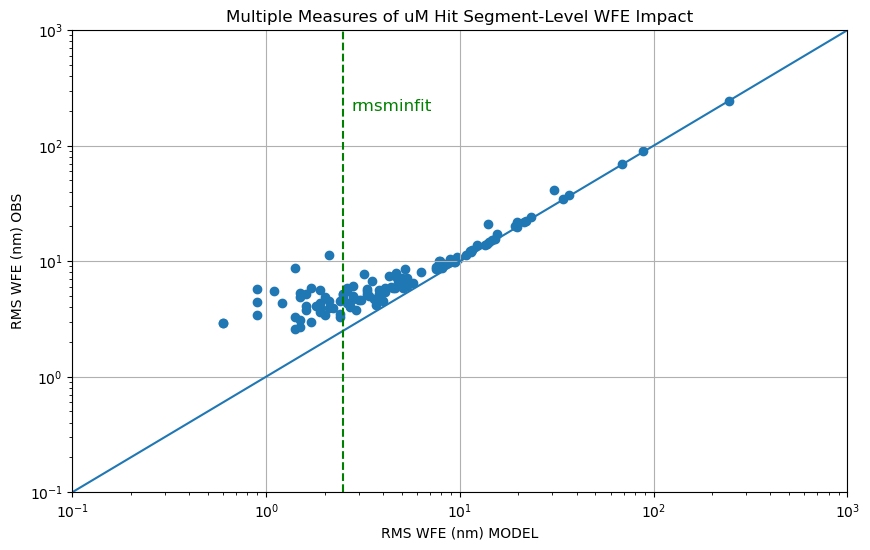

In [25]:
# For testing, make a scatter plot of rmsvalsMOD vs rmsvalsOBS

plt.figure(figsize=(10, 6))
plt.scatter(rmsvalsMOD,rmsvalsOBS)
plt.xscale('log')
plt.yscale('log')
plt.xlim(0.1, 1000.0)
plt.ylim(0.1, 1000.0)
plt.xlabel('RMS WFE (nm) MODEL') 
plt.ylabel('RMS WFE (nm) OBS')
plt.title('Multiple Measures of uM Hit Segment-Level WFE Impact')
xy1 = (0.1,0.1)
xy2 = (1000.0,1000.0)
plt.axline(xy1, xy2)
if iobstype == 1:
    plt.axvline(x=rmsminfit, color='g', linestyle='--')
    plt.text(1.1*rmsminfit, 200.0, 'rmsminfit', fontsize='large', color='g')
elif iobstype == 2: 
    plt.axhline(y=rmsminfit, color='g', linestyle='--')
    plt.text(200.0, 0.7*rmsminfit, 'rmsminfit', fontsize='large', color='g')
else:
    raise ValueError(f"Invalid value: iobstype must be 1 or 2")    
plt.grid(True)
plt.show()

## Create cumulative distribution

In [26]:
# Sort the array rmsvals
rmssort = np.sort(rmsvals)

In [27]:
# Find the index of the first element that exceeds rmsminfit
mask1 = rmssort > rmsminfit

# Find the index of the first True value
isort0 = np.argmax(mask1)

In [28]:
# For testing, write the sorted values to the screen 
# print(rmssort)
# print(isort0)

In [29]:
# Create the cumulative histogram that corresponds to these values
cumhist = np.arange(NuM)
cumhist += 1
cumhist = cumhist / NuM

In [30]:
# For testing, write the cumulative histogram to the screen 
# print(cumhist)

In [31]:
# Also calculate 1 minus the cumlulative histogram, i.e, the fraction of RMS value above a given value
cumabove = 1.0 - cumhist

# And make a version of this where the last element uses a value slightly larger value than 1,
# for plotting only, so as to avoid having log(0) at the value of the largest detected micrometeoroid hit
cumaboveplot = cumabove.copy()
cumaboveplot[NuM-1] = cumabove[NuM-1] + 0.001

# Write the arrays for testing
# print(cumabove)
# print(cumaboveplot)

## Fit broken Power Law

In [32]:
# We fit to 1 minus the observed cumulative distribution a function of the form broken_power_law defined above.
# That function is a more general version of a broken power law. It reduces to that for d to inifinity. 
# More generally, the parameter d measures the sharpness of the knee between the two segments. 
# We only include in the fit segment-level RMS values above rmsminfit. Below that, the data are thought to be 
# incomplete, because the uM hits become undetectable. 

In [33]:
# Provide an initial guess for the parameters of the function sum_of_power_laws defined above.
# A good guess helps prevent the algorithm from finding a bad local minimum.
# Initial guess format: [a, b, c, d, e]
# The values in this guess are based on experimentation.
initial_guess = [10.9, -0.74, -0.65, 30.0, 0.2]

In [34]:
# For fitting, create versions of the data arrays that are logarithmic.
# We use cumaboveplot instead of cumabove, which avoids a log(0) in the last
# element. That last element won't be used in our fitting anyway.
rmssortlog  = np.log10(rmssort)
cumaboveplotlog = np.log10(cumaboveplot)

# Create an array based on rmssortlog, which contains the midpoints of the bins defined by rmssortlog. 
# Given that the cumuluative histograms looks like a staircase (see plot below), for fitting it is best 
# to use the rmsmidlog array and to skip the last element of cumaboveplotlog. This is what we do below.
rmsmidlog = (rmssortlog[1:] + rmssortlog[:-1]) / 2

# For testing, print the arrays that we generated for testing
# print(rmssortlog)
# print(cumaboveplotlog)

# For testing, print the arrays that we will fit for testing
# print(rmsmidlog[isort0:])
# print(cumaboveplotlog[isort0:-1])

In [35]:
# Perform the fit, but only include RMS values above rmsminfit, since the detections are 
# assumed to be incomplete at lower values.

if ifittype == 1:
    # Fit the cumulative distribution points in linear-linear space
    popt, pcov = curve_fit(broken_power_law, rmssort[isort0:], cumabove[isort0:], p0=initial_guess)
elif ifittype == 2:
    # Fit the cumulative distribution points in log-log space, using midpoints to approximate the staircase nature of the 
    # empirical distribution
    popt, pcov = curve_fit(log_broken_power_law, rmsmidlog[isort0:], cumaboveplotlog[isort0:-1], p0=initial_guess)
elif (ifittype == 3):
    # Fit the cumulative distribution points in linear-linear space, but keep some parameters fixed
    # to those used in the Telfer et al. 2026) TR
    popt, pcov = curve_fit(broken_power_law_tel, rmssort[isort0:], cumabove[isort0:], p0=initial_guess)
else:
    raise ValueError(f"Invalid value: ifittype must be 1, 2, or 3")

# Extract the parameters
afit, bfit, cfit, dfit, efit = popt

# If we kept certain parameters fixed, than replace the fitted parameters by those
if ifittype == 3:
    afit = 10.9
    cfit = -1.39-bfit
    dfit = 30.0

print(f"Parameters of best-fit broken_power_law model: a={afit:.3f}, b={bfit:.3f}, c={cfit:.3f}, d={dfit:.3f}, e={efit:.3f}")
print("Note: A python warning that the Covariance of the parameters could not be estimated can be ignored")

Parameters of best-fit broken_power_law model: a=8.772, b=-0.826, c=-0.438, d=30.000, e=0.244
Note: A python warning that the Covariance of the parameters could not be estimated can be ignored


/var/folders/hf/27kk3mlj1fxgns6sw_n2g2040006lq/T/ipykernel_44119/1298040217.py:10: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(log_broken_power_law, rmsmidlog[isort0:], cumaboveplotlog[isort0:-1], p0=initial_guess)


In [36]:
# Evaluate the broken power law at array of values rmssort defined by the data
cumabovefit = vectorized_broken_power_law(rmssort,afit,bfit,cfit,dfit,efit)

In [37]:
# It is useful to consider how the fit results obtained here compare to those of the Telfer et al. (2026) TR. 
# At low RMS values, that uses a probability distribution of the form 
#   f(r) = A r^alpha  (r >= r0)
#   f(r) = 0          (r <  r0)
# with the following parameters 

Atf  = 69.8/102
r0tf = 1.5
altf = -1.40

# The value of A quoted in the report is divided here by 102. Section 3 of the 
# TR mentions that that is the number of detected uM features to date, and that appears to be the 
# total normalization of the cumulative distribution in Figure 14a. 
# This implies a cumulative distribution
#   F(r) = (A/(1+alpha)) (r^{1+alpha) - r0^{1-alpha}) 
# The function (1-F(r)) can be locally approximated as a power-law with a slope equal to the d log (1-F) / d log r. 
# This derivative can be approximated as log((1-Fb)/(1-Fa)) / log(rb/ra). Evaluating this with trial values 

ra   = 3.0
rb   = 5.0

# yields a power-law slope 

cuma = (Atf/(1.0+altf)) * ((ra**(1.0+altf)) - (r0tf**(1.0+altf))) 
cumb = (Atf/(1.0+altf)) * ((rb**(1.0+altf)) - (r0tf**(1.0+altf))) 
dlogdr = math.log((1.0-cumb)/(1.0-cuma)) / math.log(rb/ra) 

# print(cuma,cumb)
print(f"Inner power-law slope of (1-F) for Telfer et al. (2026) TR parametrization : {dlogdr:.4f}")

# The resulting value (printed below) is of similar magnitude as what is found here in the fits of the present 
# notebook for the parameters b, so this is a successful consistency check. 

# For large RMS values things are simpler. For those the Telfer et al. (2026) TR has
#   f(r) = B r^beta  (large r) , with beta = -2.39
# The result for 1-F is simply
#   (1-F(r)) = INT_r^{infinty} f(r) dr = [(B/(1+beta)) r^{1+beta}]_r^{infinty} = (B/(-1-beta)) r^{1+beta}
# So at large r, both f(r) and 1-F(r) are power laws, and they differ in slope by 1. 
# So in our fits in the present notebook we should find values for the parameter sum b+c 
# that are similar to beta+1 = -1.39, which indeed is the case. So this too is a successful consistency check. 

Inner power-law slope of (1-F) for Telfer et al. (2026) TR parametrization : -0.7393


## Monte Carlo Drawing Test

In [38]:
# Create a numpy array where each element contains a randomly drawn WFE from the distribution derived above 
rmsMC = np.array([random_WFE (afit, bfit, cfit, dfit, efit, rmsmindraw, rmsmaxdraw) for i in range(NMC)])

In [39]:
# For testing, write the values that were drawn to screen
# print(rmsMC)

In [40]:
# Sort the array rmsvals
rmsMCsort = np.sort(rmsMC)

In [41]:
# Find the index of the first element that exceeds rmsminfit
maskMC = rmsMCsort > rmsminfit

# Find the index of the first True value
isortMC0 = np.argmax(maskMC)

# Find the total number of drawings that are above rmsminfit
NMCminfit = NMC - isortMC0 

In [42]:
# Create the cumulative histogram that corresponds to these values, normalized using the range of 
# RMS value where detections are complete
cumMC = np.arange(NMC)
cumMC += 1
cumMC = cumMC / NMC

In [43]:
# Find the scaling needed to (1-cumMC) so that the MC drawings have the same fraction of hits above rmsmin
# as the real data. This used for plotting only, and not for any analysis.

# For the real data, (1-cum) at rmsmin equals (NuM-isort0)/NuM
# For the MC drawings, (1-cumMC) at rmsmin equals (NMC-isortMC0)/NMC

scaleMC = ((NuM-isort0)/NuM) / ((NMC-isortMC0)/NMC)
print(f"Scaling to apply to (1-F) so that MC and data have same fraction of hits above rmsminfit : {scaleMC:.4f}")

Scaling to apply to (1-F) so that MC and data have same fraction of hits above rmsminfit : 1.4519


## Plot Data, Fit, and Test Drawing

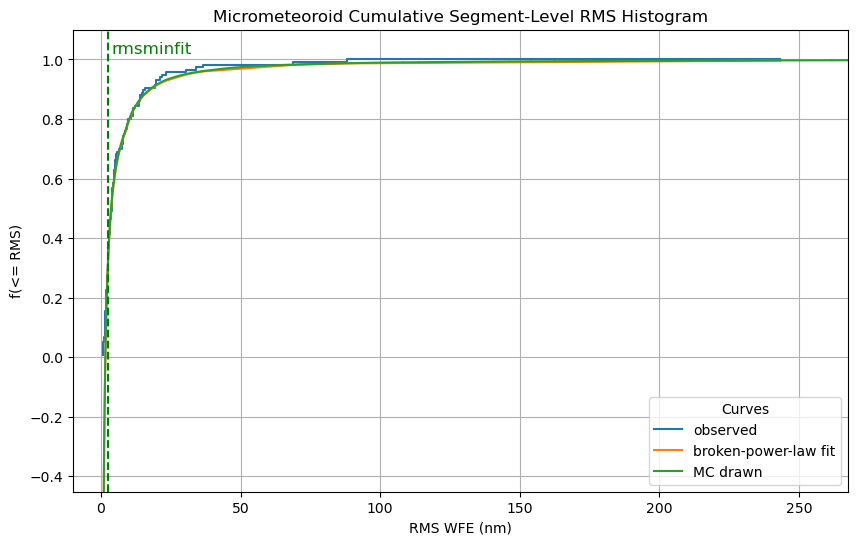

In [44]:
# Plot the cumlative distribution as a step function. 
# The where argument defines whether the step is at the start or end of each interval.

plt.figure(figsize=(10, 6))
plt.step(rmssort,cumhist,where='pre',label="observed")
plt.plot(rmssort,1.0-cumabovefit,label="broken-power-law fit")
plt.step(rmsMCsort,1.0-(scaleMC*(1.0-cumMC)),where='pre',label="MC drawn")
plt.xlim(-10.0,1.1*rmssort[NuM-1])
plt.ylim(1.0-(scaleMC*(1.0-cumMC[0])), 1.1)
plt.xlabel('RMS WFE (nm)')
plt.ylabel('f(<= RMS)')
plt.title('Micrometeoroid Cumulative Segment-Level RMS Histogram')
plt.axvline(x=rmsminfit, color='g', linestyle='--')
plt.text(1.5*rmsminfit, 1.02, 'rmsminfit', fontsize='large', color='g')
plt.legend(loc='lower right', title='Curves', fontsize='medium', frameon=True, framealpha=0.8)
plt.grid(True)
plt.show()

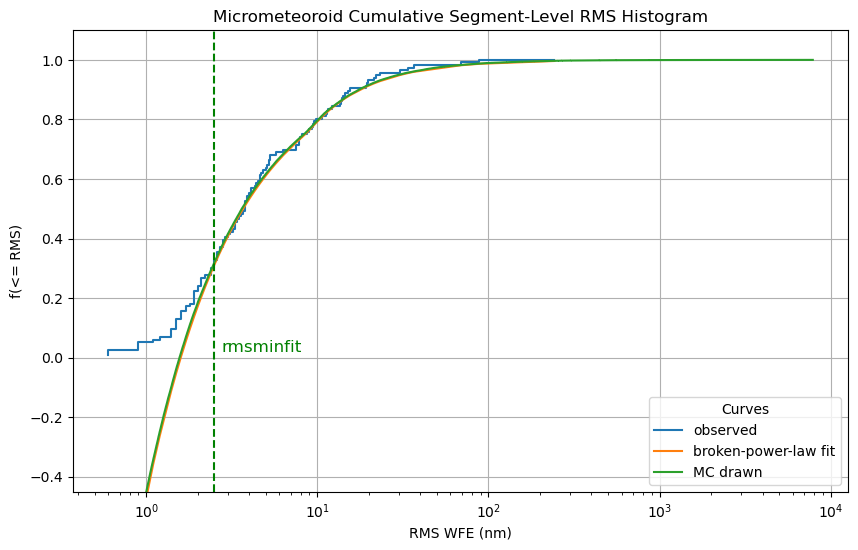

In [45]:
# Plot the cumlative distribution, but with a logarithmic x scale, as a step function. 
# The where argument defines whether the step is at the start or end of each interval.

plt.figure(figsize=(10, 6))
plt.step(rmssort,cumhist,where='pre',label="observed")
plt.plot(rmssort,1.0-cumabovefit,label="broken-power-law fit")
plt.step(rmsMCsort,1.0-(scaleMC*(1.0-cumMC)),where='pre',label="MC drawn")
plt.ylim(1.0-(scaleMC*(1.0-cumMC[0])), 1.1)
plt.xscale('log')
plt.xlabel('RMS WFE (nm)')
plt.ylabel('f(<= RMS)')
plt.title('Micrometeoroid Cumulative Segment-Level RMS Histogram')
plt.axvline(x=rmsminfit, color='g', linestyle='--')
plt.text(1.1*rmsminfit, 0.02, 'rmsminfit', fontsize='large', color='g')
plt.legend(loc='lower right', title='Curves', fontsize='medium', frameon=True, framealpha=0.8)
plt.grid(True)
plt.show()

In [46]:
# For plotting and use as initial guess (see above), we define an example broken power law with fixed parameters. 
# We take a large knee-shape parameter d, to get a sharp kink, similar to a true broken power law.
# We take our slope b+c to be identical to alpha2+1. Here alpha2 is the large-value slope 
# in eq. (2) and Figure 14 of the Telfer et al. (2026) TR. We need to add 1 to this, as discussed above.
# We take the break value a to be the same as the break r_b in Telfer. The value of e is 
# determined empirically so that the normalization roughly matches the data (see plot below).
# This leaves only b to choose. We use here the value suggested by the Telfer et al. 
# probability distribution, as derived above.
# Together, these values were used to create the initial guess for the model fit used above.
atry = 10.9
btry = -0.74
ctry = -0.65
dtry = 30.0
etry = 0.2

# Evaluate the broken power law at array of values rmssort defined by the data
cumabovetry = vectorized_broken_power_law(rmssort,atry,btry,ctry,dtry,etry)

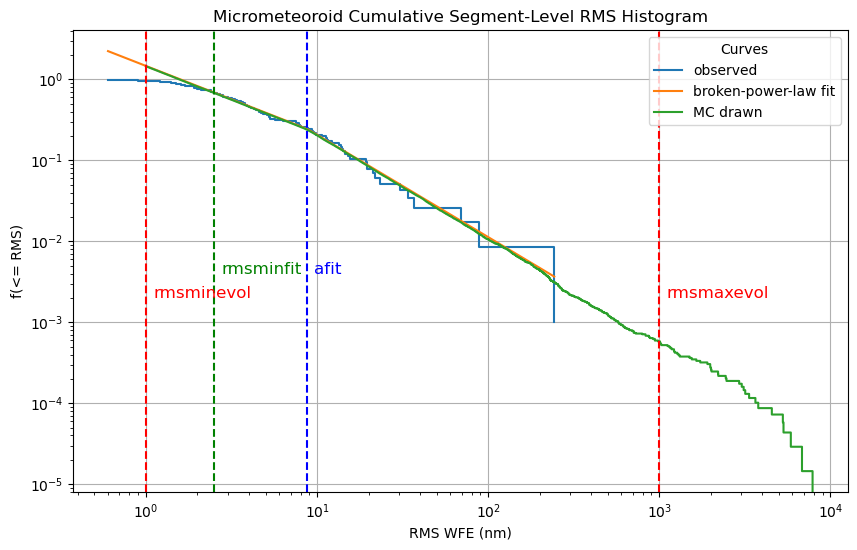

In [47]:
# Plot one minus the cumlative distribution, with a logarithmic x and y scales, as a step function. 
# The where argument defines whether the step is at the start or end of each interval.

plt.figure(figsize=(10, 6))
plt.step(rmssort,cumaboveplot,where='post',label="observed")
plt.plot(rmssort,cumabovefit,label="broken-power-law fit")
plt.step(rmsMCsort,scaleMC*(1.0-cumMC),where='post',label="MC drawn")
# plt.plot(rmssort,cumabovetry)
# plt.scatter(rmssort[isort0:], cumaboveplot[isort0:])
# plt.scatter(10.0**rmsmidlog[isort0:],10.0**cumaboveplotlog[isort0:-1])
plt.xscale('log')
plt.yscale('log')
plt.xlabel('RMS WFE (nm)')
plt.ylabel('f(<= RMS)')
plt.title('Micrometeoroid Cumulative Segment-Level RMS Histogram')
plt.axvline(x=afit , color='b', linestyle='--')
plt.text(1.1*afit, 0.004, 'afit', fontsize='large', color='b')
plt.axvline(x=rmsminfit , color='g', linestyle='--')
plt.text(1.1*rmsminfit, 0.004, 'rmsminfit', fontsize='large', color='g')
plt.axvline(x=rmsminevol, color='r', linestyle='--')
plt.text(1.1*rmsminevol, 0.002, 'rmsminevol', fontsize='large', color='r')
plt.axvline(x=rmsmaxevol, color='r', linestyle='--')
plt.text(1.1*rmsmaxevol, 0.002, 'rmsmaxevol', fontsize='large', color='r')
plt.legend(loc='upper right', title='Curves', fontsize='medium', frameon=True, framealpha=0.8)
plt.grid(True)
plt.show()

## Calculate the Average uM Impact Rate

In [48]:
# Determine the total number of uM hits above rmsminfit that have been observed
Nobs = NuM - isort0

# Determine entire time interval covered by the input file
tend   = MJDvals[NuM-1]
tstart = MJDvals[0]

# Determine the rate of hits (per day) over this time interval
# Note that this includes a small correction for the fact that the interval is bounded by know hits, not random dates.
# This changes Nobs to Nobs-1.
rate = (Nobs-1) / (tend-tstart)

# Print the result
print(f"Observed rate per day of uM hits above rmsminfit over the full tracked period : {rate:.4f}")

Observed rate per day of uM hits above rmsminfit over the full tracked period : 0.0539


In [49]:
# Determine the MJD of the start of MAZ implementation

tMAZ = get_mjd_from_string(stringMAZ)
print(f"The Modified Julian Days of the MAZ start are : {tMAZ:.2f}")

The Modified Julian Days of the MAZ start are : 60310.00


In [50]:
# Identify all hits after tMAZ that exceeded rmsminfit
mask2 = (MJDvals > tMAZ) & (rmsvals > rmsminfit)

# Find the total number of such hits
NobsMAZ = np.sum(mask2)

# Find the index of the first True value
iMAZ1 = np.argmax(mask2)

# Find the index of the last True value
iMAZ2 = len(mask2) - 1 - np.argmax(mask2[::-1])

# Print results for testing
# print(NobsMAZ)
# print(iMAZ1, MJDvals[iMAZ1], rmsvals[iMAZ1])
# print(iMAZ2, MJDvals[iMAZ2], rmsvals[iMAZ2])

In [51]:
# Determine the rate of observed hits (per day) above rmsminfit after the MAZ implementation. As above,
# this includes a small correction for the fact that the interval is bounded by know hits, not random dates.
rateMAZ = (NobsMAZ-1) / (MJDvals[iMAZ2]-MJDvals[iMAZ1])

# Print the result
print(f"Observed rate per day of uM hits above rmsminfit since MAZ implementation : {rateMAZ:.4f}")

Observed rate per day of uM hits above rmsminfit since MAZ implementation : 0.0484


In [52]:
# Calculate the correction factors to apply for these rates if we do Monte-Carlo drawings that
# extend to rms values other than rmsminfit.

cummin = 1.0 - broken_power_law(rmsmindraw, afit, bfit, cfit, dfit, efit)
cumfit = 1.0 - broken_power_law(rmsminfit , afit, bfit, cfit, dfit, efit)
cummax = 1.0 - broken_power_law(rmsmaxdraw, afit, bfit, cfit, dfit, efit)
scalerate = (cummax-cummin) / (cummax-cumfit)

# For testing, print intermediate results
# print(cummin,cumfit,cummax)

# Print inferred scaling
print(f"Change factor in the observed rate when MC drawing down to rmsmindraw : {scalerate:.4f}")

Change factor in the observed rate when MC drawing down to rmsmindraw : 2.1308


In [53]:
# For reference, we also calculate the average wait time for hits in excess of the largest one observed to date
# (extending to rmsmaxdraw)

cumbiggest   = 1.0 - broken_power_law(rmssort[NuM-1], afit, bfit, cfit, dfit, efit)
scalebiggest = (cummax-cumbiggest) / (cummax-cumfit)
ratebiggest  = rateMAZ * scalebiggest

# Print the largest hit in nm and the waiting time in years
print(f"RMS in nm of largest uM hit to date : {rmssort[NuM-1]:.2f}")
print(f"average wait time in years between hits this large or bigger : {1.0/(ratebiggest*annualdays):.2f}")

RMS in nm of largest uM hit to date : 243.20
average wait time in years between hits this large or bigger : 10.72


## Simulate WFE evolutions

In [54]:
# Calculate the average number of uM impacts per time bin.
# We use the rate determined above for the period after MAZ implementation, and 
# apply the correction factor appropriate for the RMS range we want to draw over
ratebin = rateMAZ * scalerate * tbin

In [55]:
# Set up a timeline array in days
tvals = tbin * np.arange(Nt)

# And also make a copy in calendar years
tvalsyr = today + (tvals/annualdays)

In [56]:
# Print arrays for testing
# print(tvals)

In [57]:
# Set up a matrix with simulated OTE RMS WFE evolutions in the rows
rmsOTEvals = np.zeros((Nevol,Nt))

In [58]:
# Loop over different timelines and create simulated futures

for k in range(Nevol):

# Loop over elements of the timeline, and add randomly drawn uM hits

    rmsOTEvals[k,0] = rmsOTEini
    for i in range(len(tvals)-1):
        j = i+1
        rmsOTEvals[k,j] = rmsOTEvals[k,j-1]
        if random.random() <= ratebin:
            rmsdraw = random_WFE(afit, bfit, cfit, dfit, efit, rmsmindraw, rmsmaxdraw)
            if (rmsdraw >= rmsminevol) & (rmsdraw <= rmsmaxevol):
                rmsOTEvals[k,j] = math.sqrt((rmsOTEvals[k,j]**2) + (((corfactor[icortype]*rmsdraw)**2)/Nseg))

# Note that this approach assumes that the fraction of drawings removed by the clause     
# (rmsdraw >= rmsminevol) && (rmsdraw <= rmsmaxevol) is a very small fraction of the total number of drawings,
# so that the overall rate of uM hits is not significantly affected and still consistent with that defined 
# by past experience.

## Plots and Analysis of Simulated WFE evolutions

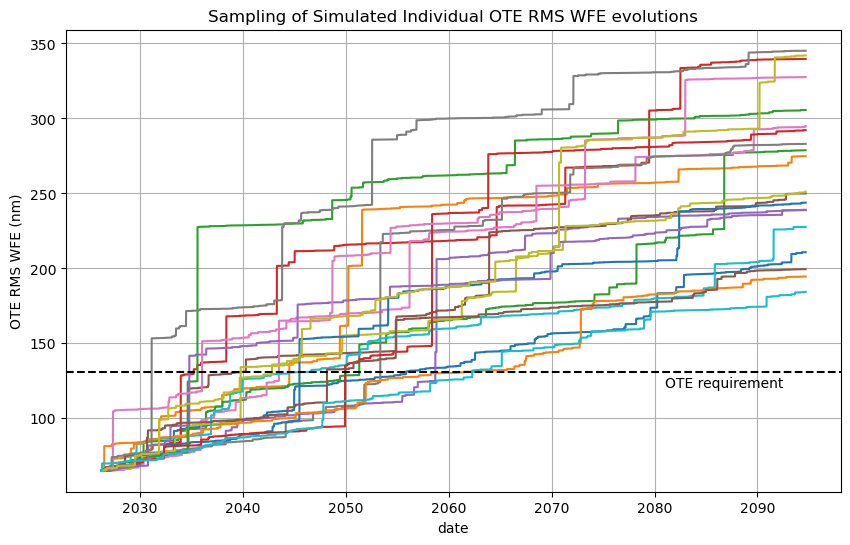

In [59]:
# Plot the simulated timelines

plt.figure(figsize=(10, 6))
for k in range(min(20,Nevol)):
    plt.plot(tvalsyr,rmsOTEvals[k,:])
plt.xlabel('date')
plt.ylabel('OTE RMS WFE (nm)')
plt.title('Sampling of Simulated Individual OTE RMS WFE evolutions')
plt.axhline(y=rmsOTEreq, color='black', linestyle='--')
plt.text(tvalsyr[int(0.8*len(tvalsyr))], 0.92*rmsOTEreq, 'OTE requirement', fontsize='medium', color='black')
plt.grid(True)
plt.show()

In [60]:
# Define perentile values of interest
Nperc = 9
percentiles = [10, 20, 30, 40, 50, 60, 70, 80, 90]

# Set up a matrix with percentiles of the simulated OTE RMS WFE evolutions in the rows
rmsOTEperc = np.zeros((9,Nt))

# Calculate the percentiles of the simulated matrix

for l in range(Nt):
    rmsOTEperc[:,l] = np.percentile(rmsOTEvals[:,l], percentiles)

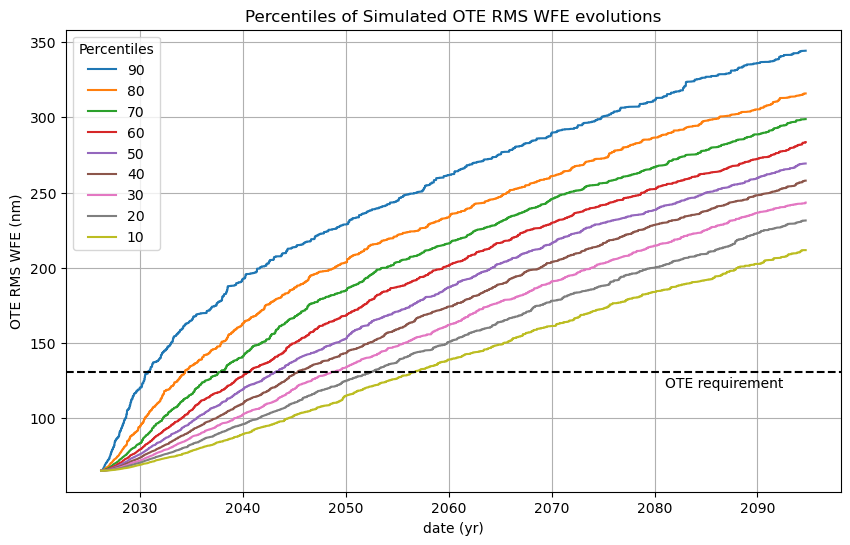

In [61]:
# Plot the percentiles of the simulated timelines

plt.figure(figsize=(10, 6))
for k in reversed(range(Nperc)):
    plt.plot(tvalsyr,rmsOTEperc[k,:],label=f"{10*(k+1):02d}")
plt.xlabel('date (yr)')
plt.ylabel('OTE RMS WFE (nm)')
plt.title('Percentiles of Simulated OTE RMS WFE evolutions')
plt.axhline(y=rmsOTEreq, color='black', linestyle='--')
plt.text(tvalsyr[int(0.8*len(tvalsyr))], 0.92*rmsOTEreq, 'OTE requirement', fontsize='medium', color='black')
plt.grid(True)
plt.legend(loc='upper left', title='Percentiles', fontsize='medium', frameon=True, framealpha=0.8)
plt.show()

In [62]:
# Find the dates at which each percentile curve intersects the value rmsOTEreq, and store results in 
# new arrays

OTEreqyr   = np.zeros(Nperc)
OTEreqperc = np.zeros(Nperc)

for k in range(Nperc):
    interp_year = np.interp(rmsOTEreq, rmsOTEperc[Nperc-k-1,:], tvalsyr)
    OTEreqperc[k] = 10.0*(k+1)
    OTEreqyr[k]   = interp_year
#    print(OTEreqperc[k],OTEreqyr[k])

print("Array of percentiles:")
print(OTEreqperc)
print(" ")
print("Array of decimal dates at which percentile curves cross rmsOTEreq")  
with np.printoptions(precision=2, suppress=True):
    print(OTEreqyr)

Array of percentiles:
[10. 20. 30. 40. 50. 60. 70. 80. 90.]
 
Array of decimal dates at which percentile curves cross rmsOTEreq
[2030.81 2034.4  2037.87 2040.67 2043.25 2045.39 2049.   2052.59 2056.79]


In [63]:
# Find the years corresponding to specific percentiles for the rmsOTEreq crossing,
# namely those for the median and +/- 1 sigma.

OTEreqyr_min  = np.interp(50.0-(0.5*perc_1sig), OTEreqperc, OTEreqyr)
OTEreqyr_med  = np.interp(50.0, OTEreqperc, OTEreqyr)
OTEreqyr_plus = np.interp(50.0+(0.5*perc_1sig), OTEreqperc, OTEreqyr)

print(f"Decimal dates of rmsOTEreq crossing as 1-sigma interval around median : {OTEreqyr_min:.2f}, {OTEreqyr_med:.2f}, {OTEreqyr_plus:.2f}")

Decimal dates of rmsOTEreq crossing as 1-sigma interval around median : 2032.91, 2043.25, 2054.33
